In [ ]:
def load_tif_numpy(tiff_path):
    """
    Load a TIFF file as a NumPy array using tifffile.
    This function is designed to work with TIFF files that may be large
    and require the imagecodecs library for efficient loading.
    """
    import numpy as np
    import os
    # import tifffile as tiff
    import rasterio

    try:
        with rasterio.open(tiff_path) as dataset:
            image_array = dataset.read()

            # --- Information about the loaded data ---
            print("Image shape (bands, rows, columns):", image_array.shape)
            print("Data type of NumPy array:", image_array.dtype)

            # Number of bands in the dataset
            print("Number of bands:", dataset.count)
            # Width of the dataset in pixels
            print("Width (columns):", dataset.width)
            # Height of the dataset in pixels
            print("Height (rows):", dataset.height)

            # --- (Optional) Accessing Geospatial Information ---
            # Even if you don't need it now, rasterio provides it
            if dataset.crs:
                print("Coordinate Reference System (CRS):", dataset.crs)
            print("Affine transform (georeferencing):", dataset.transform)
            print("Bounding box:", dataset.bounds)
            print("Data type from dataset metadata:", dataset.dtypes[0]) # Dtype of the first band

            # --- Reshaping (if needed) ---
            # If you prefer (rows, columns, bands) for libraries like Matplotlib or OpenCV:
            if image_array.ndim == 3: # Ensure it's a multi-band image
                image_array_transposed = np.transpose(image_array, (1, 2, 0))
                print("Transposed image shape (rows, columns, bands):", image_array_transposed.shape)
                # Use image_array_transposed for further processing if this shape is preferred

    except FileNotFoundError:
        print(f"Error: File not found at {tiff_file_path}")
    except rasterio.errors.RasterioIOError as e:
        print(f"Rasterio specific error: {e}")
        # This can happen if the file is not a valid raster or GDAL drivers are missing
    except Exception as e:
        print(f"An general error occurred: {e}")

    return np.squeeze(image_array_transposed, axis=-1) if image_array_transposed.ndim == 3 else image_array

In [61]:
def hist_plot(data, title='Histogram'):
    """
    Plot a histogram of the pixel values in the image.
    """
    import matplotlib.pyplot as plt
    plt.hist(data.ravel(), bins=100)
    plt.ylim(0, 1e7)
    plt.title(title)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

In [5]:
def print_stats(data):
    """
    Print statistics of the pixel values in the image.
    """
    import numpy as np
    print("Min value:", np.nanmin(data))
    print("Max value:", np.nanmax(data))
    print("Mean value:", np.nanmean(data))
    print("Median value:", np.nanmedian(data))
    print("Standard deviation:", np.nanstd(data))

In [6]:
def clean_tif(tof_data):
    tif_data[tif_data < 0] = np.nan
    nan_count = np.isnan(tif_data).sum()
    total_count = tif_data.size
    nan_percentage = 100 * nan_count / total_count
    print(f"Percentage of NaN values: {nan_percentage:.2f}%")
    return tif_data

Processing R1_7Sept23_index_blue.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 23.87%
Min value: 0.0042377994
Max value: 0.41642314
Mean value: 0.031887766
Median value: 0.029567815
Standard deviation: 0.010178661


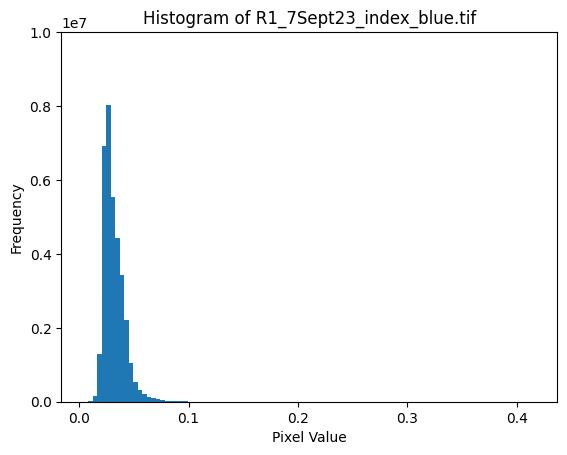

Processing R1_7Sept23_index_green.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 23.81%
Min value: 0.0077465256
Max value: 0.5023122
Mean value: 0.051726677
Median value: 0.04983034
Standard deviation: 0.018695407


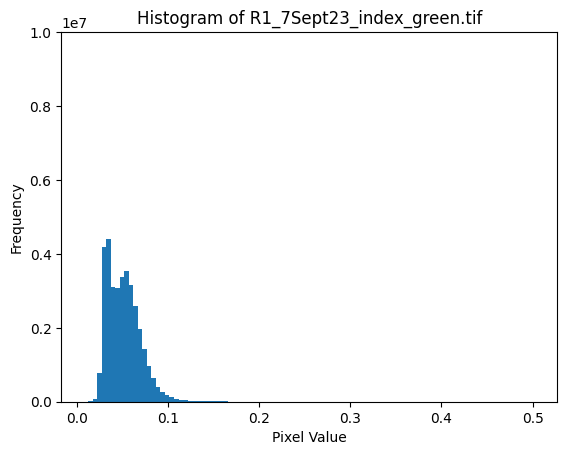

Processing R1_7Sept23_index_nir.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 23.78%
Min value: 0.02926037
Max value: 0.93166035
Mean value: 0.15555269
Median value: 0.117903255
Standard deviation: 0.11313211


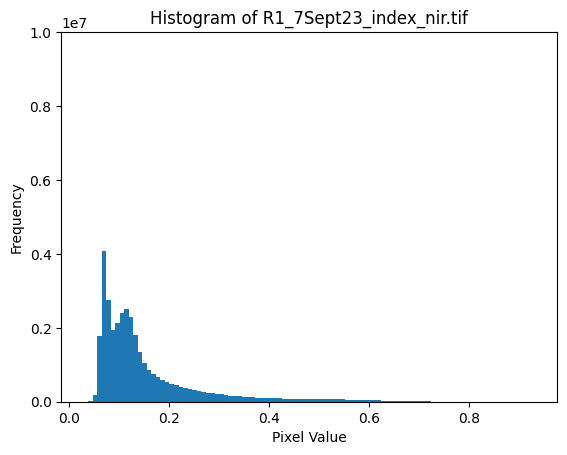

Processing R1_7Sept23_index_panchro.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 24.83%
Min value: 0.010934021
Max value: 0.5255431
Mean value: 0.06334866
Median value: 0.05876292
Standard deviation: 0.026053585


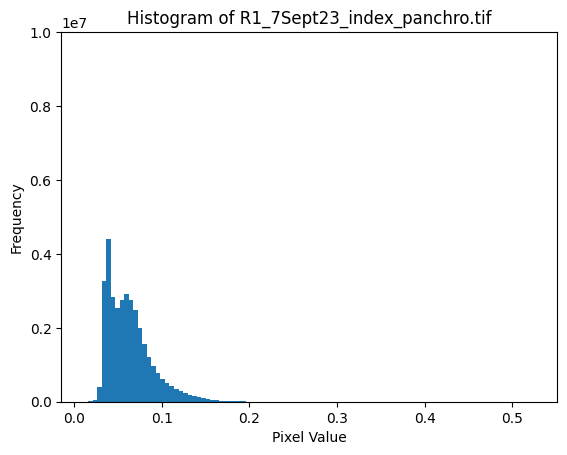

Processing R1_7Sept23_index_red.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 23.89%
Min value: 0.0048756944
Max value: 0.5417235
Mean value: 0.05886716
Median value: 0.052811746
Standard deviation: 0.021974703


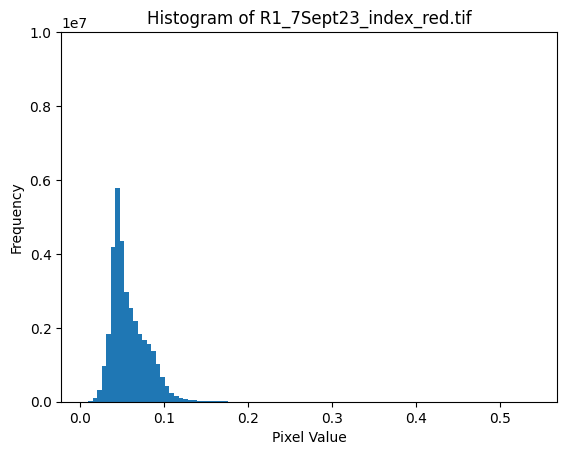

Processing R1_7Sept23_index_red_edge.tif
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143000005, bottom=2083539.7577300002, right=382777.78143000003, top=2083649.6792300001)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Percentage of NaN values: 23.81%
Min value: 0.015848892
Max value: 0.6210761
Mean value: 0.0960702
Median value: 0.08980848
Standard deviation: 0.04125439


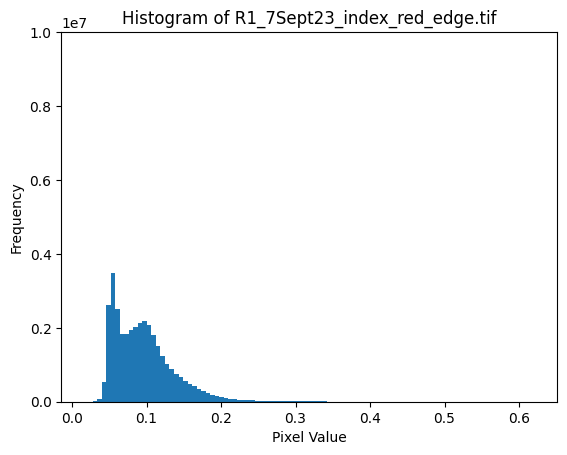

In [62]:
import os
import numpy as np

tif_folder = 'all_tif'
all_tif_data = np.empty((0, 0, 6))
for tiffile in sorted(os.listdir(tif_folder)):
    # [B, G, NIR, PANCHRO, RE, R]
    print(f'Processing {tiffile}')
    tif_path = os.path.join(tif_folder, tiffile)
    tif_data = load_tif_numpy(tif_path)
    if tif_data is not None:
        tif_data = clean_tif(tif_data)
        print_stats(tif_data)
        title = f"Histogram of {tiffile}"
        hist_plot(tif_data, title)
        # Extract the band identifier from the file name (expecting it to be the last part before the extension)
        band = os.path.splitext(tiffile)[0].split('_')[-1]
        # Define the mapping for desired channel order: [R, G, B, NIR, RE, PANCHRO]
        band_mapping = {"red": 0, "green": 1, "blue": 2, "nir": 3, "edge": 4, "panchro": 5}

        if band in band_mapping:
            channel_idx = band_mapping[band]
            # Initialize all_tif_data with the correct spatial shape on the first assignment
            if all_tif_data.size == 0:
                all_tif_data = np.empty((tif_data.shape[0], tif_data.shape[1], 6))
            all_tif_data[:, :, channel_idx] = tif_data
        else:
            print(f"Unexpected band identifier: {band}")
            break
    else:
        print(f"Failed to load {tiffile}")

In [38]:
np.shape(all_tif_data)

(5637, 8060, 6)

In [ ]:
def calculate_VIs(data):
    ''' 
    Calculate Vegetation Indices (VIs) from the data.
    make sure data has channels in the order: [R, G, B, NIR, RE, PANCHRO]
                                               0  1  2   3    4      5
    '''
    import numpy as np
    # Assuming the data is in the format [R, G, B, NIR, RE, PANCHRO]
    
    # calculate VIs
    ndvi = (data[:, :, 3] - data[:, :, 0]) / (data[:, :, 3] + data[:, :, 0])
    gndvi = (data[..., 3] - data[..., 1]) / (data[..., 3] + data[..., 1])
    ndre = (data[..., 3] - data[..., 4]) / (data[..., 3] + data[..., 4])
    ci_re = (data[..., 3] - data[..., 4]) - 1
    vari = (data[..., 1] - data[..., 0]) / (data[..., 1] + data[..., 0] - data[..., 2])
    evi2 = 2.5 * (data[..., 3] - data[..., 0]) / (data[..., 3] + 2.4 * data[..., 0] + 1)
    # MCARI = [(RedEdge - Red) - 0.2 * (RedEdge - Green)] * (RedEdge / Red)
    mcari = ((data[..., 4] - data[..., 0]) - 0.2 * (data[..., 4] - data[..., 1])) * (data[..., 4] / data[..., 0])
    norm2 = (data[..., 0] - data[..., 1]) / (data[..., 0] + data[..., 1])
    
    vis = np.stack((ndvi, gndvi, ndre, ci_re, vari, evi2, mcari, norm2), axis=-1)
    print("VIs shape:", vis.shape)
    return vis

In [49]:
vis = calculate_VIs(all_tif_data)

VIs shape: (5637, 8060, 8)


In [43]:
np.nansum(vis[0])

np.float64(12534543.675638497)

Percentage of NaN values: 23.81%


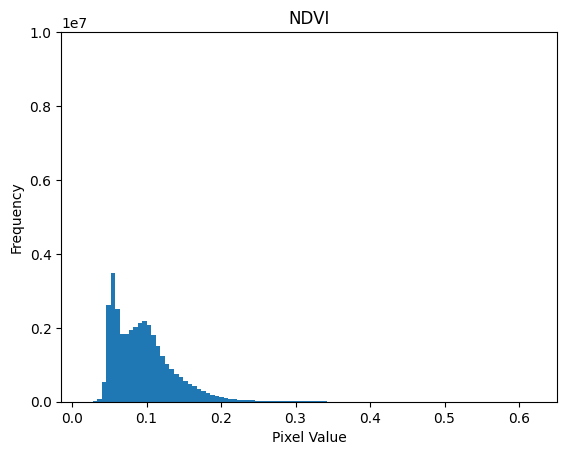

Percentage of NaN values: 23.81%
Min value: 0.015848892
Max value: 0.6210761
Mean value: 0.0960702
Median value: 0.08980848
Standard deviation: 0.04125439


In [65]:
hist_plot(clean_tif(vis[0]), 'NDVI')
print_stats(clean_tif(vis[0]))

In [74]:
import rasterio
# Replace np.nan with a designated nodata value
nodata_value = -10000
output_array = np.where(np.isnan(vis), nodata_value, vis).astype('float32')

# Rasterio expects data in (bands, rows, cols), so we transpose the array
output_array = np.expand_dims(np.transpose(output_array, (2, 0, 1))[0], axis=0)
print("Output array shape:", output_array.shape)
# Create a profile for the output TIFF file.
profile = {
    'driver': 'GTiff',
    'dtype': 'float32',
    'nodata': nodata_value,
    'height': output_array.shape[1],
    'width': output_array.shape[2],
    'count': output_array.shape[0],
    'compress': 'lzw'
}

output_path = 'ndvi_output.tif'
with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(output_array)
    
print(f"Saved TIFF file with nodata={nodata_value} to {output_path}")

Output array shape: (1, 5637, 8060)


/raid/biplab/souravr/miniconda3/envs/crop/lib/python3.11/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Saved TIFF file with nodata=-10000 to ndvi_output.tif


In [ ]:
def get_regions(all_tif_data):
    import os
    import numpy as np
    import rasterio
    from rasterio import features
    from skimage import measure
    from skimage.measure import regionprops
    from skimage.morphology import remove_small_objects

    # Paths
    input_path = "/content/R1_28Aug23_index_ndvi.tif"
    output_dir = "ndvi_regions"
    os.makedirs(output_dir, exist_ok=True)

    # Read the NDVI image
    with rasterio.open(input_path) as src:
        ndvi = src.read(1)
        profile = src.profile

    # Optional: Threshold to remove background or invalid NDVI (e.g., water, buildings)
    binary_mask = ndvi > 0.05  # Change threshold as needed
    binary_mask = remove_small_objects(binary_mask, min_size=100)  # Filter small noise

    # Label connected regions
    labeled_mask = measure.label(binary_mask, connectivity=2)
    regions = regionprops(labeled_mask)

    print(f"Found {len(regions)} regions.")

    # Save each region as a separate GeoTIFF
    for region in regions:
        # Create a mask where the region pixels have their original NDVI value, and others are 0
        region_mask = np.where(labeled_mask == region.label, ndvi, 0)

        out_path = os.path.join(output_dir, f"region_{region.label}.tif")
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(region_mask, 1)

    print(f"Saved {len(regions)} region TIFFs to {output_dir}")


In [73]:
output_array.shape

(1, 5637, 8060)

In [75]:
my_ndvi = load_tif_numpy('ndvi_output.tif')
soft_ndvi = load_tif_numpy('NDVI.tif')

/raid/biplab/souravr/miniconda3/envs/crop/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Affine transform (georeferencing): | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=0.0, bottom=5637.0, right=8060.0, top=0.0)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)
Image shape (bands, rows, columns): (1, 5637, 8060)
Data type of NumPy array: float32
Number of bands: 1
Width (columns): 8060
Height (rows): 5637
Coordinate Reference System (CRS): EPSG:32643
Affine transform (georeferencing): | 0.02, 0.00, 382620.61|
| 0.00,-0.02, 2083649.68|
| 0.00, 0.00, 1.00|
Bounding box: BoundingBox(left=382620.61143, bottom=2083539.75773, right=382777.78143, top=2083649.67923)
Data type from dataset metadata: float32
Transposed image shape (rows, columns, bands): (5637, 8060, 1)


In [84]:
print((my_ndvi.shape[0]*my_ndvi.shape[1] - (my_ndvi == soft_ndvi).sum()) / (my_ndvi.shape[0]*my_ndvi.shape[1]))

0.0


In [82]:
my_ndvi[my_ndvi == -10000] = soft_ndvi[0][0]

In [81]:
soft_ndvi

array([[-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       ...,
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38]],
      shape=(5637, 8060), dtype=float32)

In [83]:
my_ndvi

array([[-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       ...,
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38],
       [-3.4028235e+38, -3.4028235e+38, -3.4028235e+38, ...,
        -3.4028235e+38, -3.4028235e+38, -3.4028235e+38]],
      shape=(5637, 8060), dtype=float32)

In [1]:
def get_aoi(tiffile, boundbox):
    """
    Get the area of interest (AOI) from a TIFF file based on a bounding box.
    """
    import rasterio
    from rasterio.windows import from_bounds

    with rasterio.open(tiffile) as src:
        # Get the window based on the bounding box
        window = from_bounds(boundbox[0], boundbox[1], boundbox[2], boundbox[3], transform=src.transform)
        aoi = src.read(window=window)
        print(f"AOI shape: {aoi.shape}")
        return aoi

# Test usecase
points =    [
                [
                    4375.737704918032,
                    856.3688524590167
                ],
                [
                    3392.5000000000005,
                    4974.75
                ],
                [
                    5146.25,
                    5439.75
                ],
                [
                    6133.846153846152,
                    1310.8076923076924
                ]
            ]
tiffile = '/raid/biplab/souravr/TIH/CROP/output/ndvi_output.tif'
aoi = get_aoi(tiffile, points)


/raid/biplab/souravr/miniconda3/envs/crop/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [10]:
from src.utils import *
# reload module forcefully
import importlib
import src.compressor
importlib.reload(src.compressor)
from src.compressor import *

# data = load_tif_numpy_with_meta('/raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices.tif')
compress = compress_multi('/raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices.tif', '/raid/biplab/souravr/TIH/CROP/output')

Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_0.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_1.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_2.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_3.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_4.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_5.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_6.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices_7.png


In [21]:
from src import utils as myUtils
data, meta, transform, crs = myUtils.load_tif_numpy_with_meta(
    '/raid/biplab/souravr/TIH/CROP/output/ndvi_output.tif')

/raid/biplab/souravr/miniconda3/envs/crop/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [22]:
for band in data:
    print(np.isnan(band).sum()/band.size)

0.0


Found 16 regions.


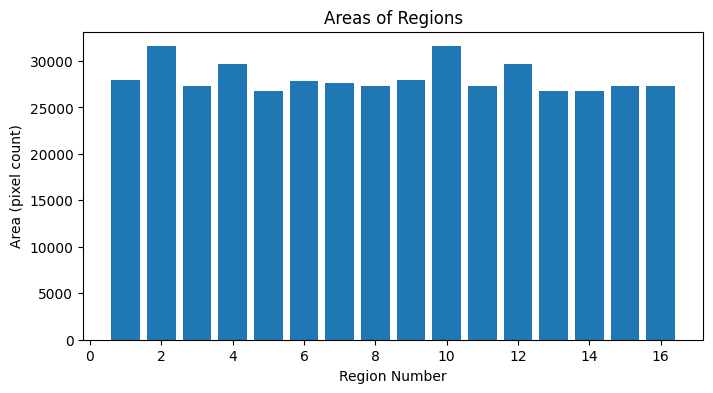

In [14]:
import os
import numpy as np
import rasterio
from rasterio import features
from skimage import measure
from skimage.measure import regionprops
from skimage.morphology import remove_small_objects

import importlib
import src.mask_me
importlib.reload(src.mask_me)
from src.mask_me import *

# Paths
input_path = "/raid/biplab/souravr/TIH/CROP/output/7Sept23_8_indices.tif"
out_folder = input_path.split('/')[-1].split('.')[0]
output_dir = os.path.join(
    "/raid/biplab/souravr/TIH/CROP/output/regions",
    out_folder
)
os.makedirs(output_dir, exist_ok=True)
regions_json = '/raid/biplab/souravr/TIH/CROP/data/trail1_regions.json'

regions = get_polygon_from_json(regions_json)
print(f"Found {len(regions)} regions.")

import matplotlib.pyplot as plt

region_areas = []
for region in regions:
    region_areas.append(region.area)

# Bar plot to summarize all regions.
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(region_areas) + 1), region_areas)
plt.xlabel("Region Number")
plt.ylabel("Area (pixel count)")
plt.title("Areas of Regions")
plt.show()

# for region in regions:
#     mask_shape = 
#     region_mask = create_mask_from_polygon(region, )

In [6]:
from src.compressor import compress_multi
import os
folder = '/raid/biplab/souravr/TIH/CROP/output/regions/7Sept23_8_indices'
for file in sorted(os.listdir(folder)):
    file_path = os.path.join(folder, file)
    compress_multi(
        file_path,
        '/raid/biplab/souravr/TIH/CROP/output/compressed/regions'
    )

Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/00.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/01.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/02.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/03.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/04.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/05.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/06.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_1/07.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_10/00.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_10/01.png
Preview saved as /raid/biplab/souravr/TIH/CROP/output/compressed/regions/region_10/02.png
Preview saved as /

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio

# List all TIFF files in the folder
tif_files = [f for f in os.listdir(folder) if f.endswith('.tif')]

stats = []
for tif_file in tif_files:
    full_path = os.path.join(folder, tif_file)
    with rasterio.open(full_path) as src:
        # Read the first band for summary stats
        data = src.read()
    for band in data:
        stats.append({
            'filename': tif_file,
            'shape': data.shape,
            'min': np.nanmin(data),
            'max': np.nanmax(data),
            'mean': np.nanmean(data),
            'median': np.nanmedian(data),
            'std': np.nanstd(data),
            'nan_count': np.isnan(data).sum(),
            'total_pixels': data.size,
            'nan_percentage': 100 * np.isnan(data).sum() / data.size
        })

df_tif_stats = pd.DataFrame(stats)
df_tif_stats

In [2]:
import os
import re

folder = '/raid/biplab/souravr/TIH/CROP/output2/trail_1/14Sept23'
for filename in sorted(os.listdir(folder)):
    if filename.endswith('.tif'):
        match = re.match(r'region_R(\d+)T(\d+)\.tif$', filename)
        if match:
            new_name = f"R{match.group(1)}T{match.group(2)}_VIs.tif"
            old_path = os.path.join(folder, filename)
            new_path = os.path.join(folder, new_name)
            os.rename(old_path, new_path)
            print(f"Renamed {filename} to {new_name}")

Renamed region_R1T1.tif to R1T1_VIs.tif
Renamed region_R1T2.tif to R1T2_VIs.tif
Renamed region_R1T3.tif to R1T3_VIs.tif
Renamed region_R1T4.tif to R1T4_VIs.tif
Renamed region_R1T5.tif to R1T5_VIs.tif
Renamed region_R2T1.tif to R2T1_VIs.tif
Renamed region_R2T2.tif to R2T2_VIs.tif
Renamed region_R2T3.tif to R2T3_VIs.tif
Renamed region_R2T4.tif to R2T4_VIs.tif
Renamed region_R2T5.tif to R2T5_VIs.tif
Renamed region_R3T1.tif to R3T1_VIs.tif
Renamed region_R3T2.tif to R3T2_VIs.tif
Renamed region_R3T3.tif to R3T3_VIs.tif
Renamed region_R3T4.tif to R3T4_VIs.tif
Renamed region_R3T5.tif to R3T5_VIs.tif


In [5]:
import geopandas as gpd
gdf_regions = gpd.read_file("/raid/biplab/souravr/TIH/CROP/data/field_regions.gpkg")
print(gdf_regions)
print(gdf_regions.crs)

    id region_id                                           geometry
0    1      R1T2  MULTIPOLYGON (((382714.643 2083630.677, 382722...
1    0      R1T1  MULTIPOLYGON (((382705.972 2083632.96, 382713....
2    3      R1T4  MULTIPOLYGON (((382731.878 2083626.102, 382739...
3    2      R1T3  MULTIPOLYGON (((382723.207 2083628.385, 382731...
4    5      R2T1  MULTIPOLYGON (((382714.149 2083629.094, 382722...
5    4      R1T5  MULTIPOLYGON (((382705.478 2083631.377, 382713...
6    7      R2T3  MULTIPOLYGON (((382731.383 2083624.52, 382739....
7    6      R2T2  MULTIPOLYGON (((382722.712 2083626.803, 382730...
8    9      R2T5  MULTIPOLYGON (((382713.778 2083627.635, 382721...
9    8      R2T4  MULTIPOLYGON (((382705.107 2083629.918, 382713...
10  11      R3T2  MULTIPOLYGON (((382731.012 2083623.061, 382738...
11  10      R3T1  MULTIPOLYGON (((382722.341 2083625.344, 382730...
12  13      R3T4  MULTIPOLYGON (((382713.283 2083626.053, 382721...
13  12      R3T3  MULTIPOLYGON (((382704.612 208

In [1]:
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling, calculate_default_transform, Affine
import numpy as np
from skimage.registration import phase_cross_correlation
import os

def get_shifted_transform(slave_dataset, dx_pixels, dy_pixels):
    """Calculates a new Affine transform for a shifted image."""
    # Original transform: (a, b, c, d, e, f)
    # c = top-left x, f = top-left y
    # New top-left x = c + dx_pixels * pixel_width_x
    # New top-left y = f + dy_pixels * pixel_height_y (note: pixel_height_y is often negative)
    original_transform = slave_dataset.transform
    new_c = original_transform.c + dx_pixels * original_transform.a
    new_f = original_transform.f + dy_pixels * original_transform.e
    return Affine(original_transform.a, original_transform.b, new_c,
                  original_transform.d, original_transform.e, new_f)

def coregister_image_translation_phase_corr(master_tif_path, slave_tif_path, output_tif_path, band_to_use=1):
    """
    Co-registers slave_tif to master_tif using phase correlation for translational shifts.
    Saves the co-registered slave image (by adjusting its transform).
    """
    try:
        with rasterio.open(master_tif_path) as master_ds, rasterio.open(slave_tif_path) as slave_ds:
            # Ensure CRSs are compatible (ideally the same) - this method doesn't reproject CRSs
            if master_ds.crs != slave_ds.crs:
                print(f"Warning: Master CRS ({master_ds.crs}) and Slave CRS ({slave_ds.crs}) differ. "
                      "Phase correlation works on pixel shifts, not geographic reprojection.")
                # For robust solution, reproject slave_ds to master_ds.crs first
                # This example proceeds assuming CRSs are at least compatible for overlap.

            # Read the specified band for correlation
            master_band = master_ds.read(band_to_use).astype(np.float32)
            slave_band = slave_ds.read(band_to_use).astype(np.float32)

            # --- Optional: Use a common overlapping area if images are not same size/extent ---
            # This requires calculating the geographic intersection and then converting to pixel windows
            # For simplicity here, we assume images are roughly overlapping and of similar size
            # A more robust implementation would find the intersection first.
            # For now, let's take the minimum dimensions if they differ.
            h = min(master_band.shape[0], slave_band.shape[0])
            w = min(master_band.shape[1], slave_band.shape[1])
            master_band_crop = master_band[:h, :w]
            slave_band_crop = slave_band[:h, :w]

            # Normalize for brightness differences (optional but can help)
            master_band_crop = (master_band_crop - np.mean(master_band_crop)) / (np.std(master_band_crop) + 1e-7)
            slave_band_crop = (slave_band_crop - np.mean(slave_band_crop)) / (np.std(slave_band_crop) + 1e-7)

            # Calculate the shift using phase cross-correlation
            # shift is (dy, dx) - row shift, column shift
            shift, error, phasediff = phase_cross_correlation(
                master_band_crop, slave_band_crop, upsample_factor=10 # Upsampling improves sub-pixel accuracy
            )
            dy_pixels, dx_pixels = shift
            print(f"Detected shift (dy, dx) in pixels: ({dy_pixels:.2f}, {dx_pixels:.2f})")

            # --- Apply the shift ---
            # Option A: Modify the affine transform of the slave image
            # This is non-destructive to pixel values but changes georeferencing.
            # The output will have the same pixel data as the original slave,
            # but its georeferencing metadata will be shifted.
            new_transform = get_shifted_transform(slave_ds, dx_pixels, dy_pixels)
            
            profile = slave_ds.profile.copy()
            profile.update({
                'transform': new_transform,
                'crs': slave_ds.crs # Keep original CRS, just shift position
            })

            with rasterio.open(output_tif_path, 'w', **profile) as dst:
                dst.write(slave_ds.read()) # Write all bands from original slave

            print(f"Co-registered (shifted transform) slave image saved to: {output_tif_path}")
            return output_tif_path

            # --- Option B: Resample/Warp the slave image (more computationally intensive) ---
            # This creates a new raster with pixel values shifted, potentially onto the master's grid.
            # (This part is more complex to implement correctly for sub-pixel shifts and all bands)
            # For sub-pixel shifts, resampling is necessary.
            #
            # shifted_slave_data = np.empty_like(slave_ds.read())
            #
            # # This is a simplified warp; a full reproject might be better
            # # We want to create an output that has the slave_data shifted onto the master's grid
            # # effectively by -dy, -dx to align
            #
            # # Calculate the transform for the output (slave data on master's grid)
            # # This assumes the output should align with the master's grid
            # dst_transform = master_ds.transform
            # dst_crs = master_ds.crs
            # dst_height = master_ds.height
            # dst_width = master_ds.width
            #
            # # The source data (slave) needs to appear shifted by -dy, -dx
            # # We can achieve this by modifying the slave's transform for the reprojection
            # src_shifted_transform = get_shifted_transform(slave_ds, -dx_pixels, -dy_pixels)
            #
            # out_profile = master_ds.profile.copy()
            # out_profile.update({
            #     'count': slave_ds.count, # Number of bands from slave
            #     'dtype': slave_ds.dtypes[0] # Dtype from slave
            # })
            #
            # with rasterio.open(output_tif_path, 'w', **out_profile) as dst:
            #     for i in range(1, slave_ds.count + 1):
            #         reproject(
            #             source=rasterio.band(slave_ds, i),
            #             src_transform=src_shifted_transform, # Use the effectively 'pre-shifted' source
            #             src_crs=slave_ds.crs,
            #             destination=rasterio.band(dst, i),
            #             dst_transform=dst_transform,
            #             dst_crs=dst_crs,
            #             resampling=Resampling.nearest # or bilinear, cubic
            #         )
            # print(f"Co-registered (warped) slave image saved to: {output_tif_path}")
            # return output_tif_path


    except Exception as e:
        print(f"Error during co-registration: {e}")
        return None

# Example Usage:
master_image = "/raid/biplab/souravr/TIH/CROP/data/7Sept23/R1_7Sept23_index_blue.tif"
slave_image_to_register = "/raid/biplab/souravr/TIH/CROP/data/28Aug23/R1_28Aug23_index_nir.tif"
output_coregistered_slave = "/raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered.tif"

coregistered_file = coregister_image_translation_phase_corr(
    master_image,
    slave_image_to_register,
    output_coregistered_slave
)
if coregistered_file:
    print(f"Use {coregistered_file} for your masking operations.")

Detected shift (dy, dx) in pixels: (-1571.00, -2052.10)
Co-registered (shifted transform) slave image saved to: /raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered.tif
Use /raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered.tif for your masking operations.


In [4]:
import cv2
# ... other imports like rasterio, numpy ...

def coregister_image_feature_based(master_tif_path, slave_tif_path, output_tif_path, band_to_use=1,
                                   method='translation_only'): # method can be 'translation_only' or 'affine'
    try:
        with rasterio.open(master_tif_path) as master_ds, rasterio.open(slave_tif_path) as slave_ds:
            master_band = master_ds.read(band_to_use)
            slave_band = slave_ds.read(band_to_use)

            # Convert to 8-bit for many OpenCV feature detectors
            master_8bit = ((master_band - master_band.min()) / (master_band.max() - master_band.min()) * 255).astype(np.uint8)
            slave_8bit = ((slave_band - slave_band.min()) / (slave_band.max() - slave_band.min()) * 255).astype(np.uint8)

            # Initialize ORB detector (or SIFT, SURF - SIFT/SURF might not be in default OpenCV builds)
            orb = cv2.ORB_create(nfeatures=2000) # Increase nfeatures for more complex scenes
            kp1, des1 = orb.detectAndCompute(master_8bit, None)
            kp2, des2 = orb.detectAndCompute(slave_8bit, None)

            if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
                print("Not enough descriptors found. Try SIFT or adjust ORB parameters.")
                return None

            # Match descriptors
            bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            matches = bf.match(des1, des2)
            matches = sorted(matches, key=lambda x: x.distance) # Sort by distance

            # Keep only good matches (e.g., top 10% or a fixed number)
            good_matches_count = max(10, int(len(matches) * 0.15))
            good_matches = matches[:good_matches_count]

            if len(good_matches) < 4: # Need at least 4 for affine/homography, or a few for robust translation
                print("Not enough good matches found.")
                return None

            # Extract location of good matches
            pts_master = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            pts_slave = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            if method == 'translation_only':
                # Calculate average dx, dy
                # Note: OpenCV points are (x, y) which is (col, row)
                dx_values = pts_master[:, 0, 0] - pts_slave[:, 0, 0]
                dy_values = pts_master[:, 0, 1] - pts_slave[:, 0, 1]
                
                # Use median for robustness to outliers
                dx_pixels = np.median(dx_values) # slave needs to move by +dx_pixels to match master
                dy_pixels = np.median(dy_values) # slave needs to move by +dy_pixels to match master

                print(f"Feature-based median shift (dy_pixels, dx_pixels): ({dy_pixels:.2f}, {dx_pixels:.2f})")
                
                # This dx, dy is how much the SLAVE's coordinates need to change to match MASTER's
                # So, if master_pt = slave_pt + (dx, dy), then slave_pt = master_pt - (dx,dy)
                # The shift for get_shifted_transform is how much slave's origin moves.
                # If a point on slave (Ps) needs to move by (dx, dy) to align with master (Pm),
                # Pm.x = Ps.x + dx  =>  Ps.x = Pm.x - dx
                # Pm.y = Ps.y + dy  =>  Ps.y = Pm.y - dy
                # The transform describes mapping from pixel to geo.
                # If we want slave pixel (0,0) to map to where master pixel (-dx, -dy) would have mapped,
                # we want the slave image to effectively shift by (+dx, +dy) in pixel space.
                new_transform = get_shifted_transform(slave_ds, dx_pixels, dy_pixels)

            elif method == 'affine':
                # Estimate affine transformation (includes translation, rotation, scale, shear)
                # This gives a 2x3 matrix M
                M, mask = cv2.estimateAffinePartial2D(pts_slave, pts_master, method=cv2.RANSAC, ransacReprojThreshold=3.0)
                if M is None:
                    print("Could not estimate affine transform.")
                    return None
                
                # M is [[a, b, tx], [c, d, ty]]
                # We need to convert this pixel-space transform matrix M
                # into an update for the georeferencing affine transform.
                # This is more complex than simple translation.
                # For simplicity, if affine is chosen, one usually warps the image pixels.
                # Warping the slave image:
                h_s, w_s = slave_band.shape
                warped_slave_data = np.empty_like(slave_ds.read())
                for i in range(slave_ds.count):
                    band_data = slave_ds.read(i + 1)
                    # Warp slave to align with master. Output size is master's size.
                    # This assumes master and slave should align on master's grid.
                    warped_slave_data[i] = cv2.warpAffine(band_data, M, (master_ds.width, master_ds.height),
                                                          flags=cv2.INTER_NEAREST, # Or cv2.INTER_LINEAR
                                                          borderMode=cv2.BORDER_CONSTANT,
                                                          borderValue=slave_ds.nodata or 0)

                profile = master_ds.profile.copy() # Output uses master's georeferencing and extent
                profile.update({
                    'count': slave_ds.count,
                    'dtype': slave_ds.dtypes[0],
                    'nodata': slave_ds.nodata
                })
                with rasterio.open(output_tif_path, 'w', **profile) as dst:
                    dst.write(warped_slave_data)
                print(f"Co-registered (affine warped) slave image saved to: {output_tif_path}")
                return output_tif_path

            else:
                print(f"Unknown method: {method}")
                return None

            # If method was 'translation_only', proceed to save with shifted transform
            profile = slave_ds.profile.copy()
            profile.update({'transform': new_transform})
            with rasterio.open(output_tif_path, 'w', **profile) as dst:
                dst.write(slave_ds.read())
            print(f"Co-registered (feature-based shifted transform) slave image saved to: {output_tif_path}")
            return output_tif_path

    except Exception as e:
        print(f"Error during feature-based co-registration: {e}")
        return None

# Example Usage:
master_image = "/raid/biplab/souravr/TIH/CROP/data/7Sept23/R1_7Sept23_index_blue.tif"
slave_image = "/raid/biplab/souravr/TIH/CROP/data/28Aug23/R1_28Aug23_index_blue.tif"
output_tif_path = "/raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered_cv2.tif"
coregistered_file = coregister_image_feature_based(
    master_image,
    slave_image,
    output_tif_path,
    method='translation_only' # or 'affine'
)
if coregistered_file:
    print(f"Use {coregistered_file} for your masking operations.")

Feature-based median shift (dy_pixels, dx_pixels): (-2762.64, -1450.80)
Co-registered (feature-based shifted transform) slave image saved to: /raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered_cv2.tif
Use /raid/biplab/souravr/TIH/CROP/output/28Aug23_coregistered_cv2.tif for your masking operations.


In [6]:
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
import numpy as np
import os

def resample_to_master_grid(master_tif_path, slave_tif_path, output_resampled_slave_tif_path):
    """
    Resamples/warps the slave TIFF to match the grid (CRS, transform, dimensions)
    of the master TIFF.
    """
    try:
        with rasterio.open(master_tif_path) as master_ds:
            dst_crs = master_ds.crs
            dst_transform = master_ds.transform
            dst_height = master_ds.height
            dst_width = master_ds.width
            dst_profile = master_ds.profile.copy() # Get full profile for output

        with rasterio.open(slave_tif_path) as slave_ds:
            # Prepare output array. Output will have master's dimensions but slave's band count and dtype.
            # Update the profile for the output based on slave's band count and dtype
            # but master's geometry.
            dst_profile.update({
                'crs': dst_crs,
                'transform': dst_transform,
                'width': dst_width,
                'height': dst_height,
                'count': slave_ds.count, # Use slave's band count
                'dtype': slave_ds.dtypes[0], # Use slave's data type for the first band (assumes all bands same dtype)
                'nodata': slave_ds.nodata # Propagate NoData value from slave
            })
            # If master has a different nodata value you want to use for the output canvas:
            # if master_ds.nodata is not None:
            #     dst_profile['nodata'] = master_ds.nodata


            # Create an empty array for the destination
            # Note: reproject works band by band
            resampled_slave_array = np.empty((slave_ds.count, dst_height, dst_width), dtype=slave_ds.dtypes[0])

            reproject(
                source=slave_ds.read(), # Read all bands from slave
                destination=resampled_slave_array,
                src_transform=slave_ds.transform,
                src_crs=slave_ds.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest # Important choice!
                # Other options: Resampling.bilinear, Resampling.cubic, etc.
                # Nearest Neighbor is best for preserving original values for VIs,
                # but can look blocky if resolutions are very different.
                # Bilinear is smoother but alters values.
            )

        # Save the resampled slave image
        with rasterio.open(output_resampled_slave_tif_path, 'w', **dst_profile) as dst:
            dst.write(resampled_slave_array)

        print(f"Resampled slave image saved to: {output_resampled_slave_tif_path}")
        return output_resampled_slave_tif_path

    except Exception as e:
        print(f"Error during resampling of {slave_tif_path}: {e}")
        return None

# --- Example Usage in your pipeline ---
master_image_path = "/raid/biplab/souravr/TIH/CROP/data/4Days/R1_7Sept23_index_panchro.tif" # Your reference image

slave_images_to_process = [
    "/raid/biplab/souravr/TIH/CROP/data/4Days/R1_28Aug23_index_panchro.tif",
    "/raid/biplab/souravr/TIH/CROP/data/4Days/R1_14Sep23_index_panchro.tif",
    "/raid/biplab/souravr/TIH/CROP/data/4Days/R1_25Sept23_index_panchro.tif",
]

output_dir_for_resampled = "/raid/biplab/souravr/TIH/CROP/output/resampled_images/"
os.makedirs(output_dir_for_resampled, exist_ok=True)

for slave_path in slave_images_to_process:
    base_name = os.path.splitext(os.path.basename(slave_path))[0]
    resampled_output_path = os.path.join(output_dir_for_resampled, f"{base_name}_resampled_to_master.tif")
    
    aligned_slave_path = resample_to_master_grid(master_image_path, slave_path, resampled_output_path)
    
    if aligned_slave_path:
        print(f"Resampled slave image saved to: {aligned_slave_path}")
        # Now, `aligned_slave_path` should have the same pixel grid as your master.
        # You can try your `phase_cross_correlation` on this `aligned_slave_path`
        # and the `master_image_path`. The detected shift *should* be very small (ideally close to 0,0).
        # If there are still minor shifts, phase correlation can correct those.

        # OR, if the resampling is good enough, you might be able to directly use
        # `aligned_slave_path` for your AOI masking without further phase correlation.

        # Example: Proceeding with phase correlation for fine-tuning
        output_coregistered_path = os.path.join(output_dir_for_resampled, f"{base_name}_coreg.tif")
        fine_tuned_path = coregister_image_translation_phase_corr(
        master_image_path,
        aligned_slave_path, # Use the resampled image
        output_coregistered_path
        )
        # if fine_tuned_path:
        # tif_to_aoi_pipeline(fine_tuned_path, ...)
        # else: # Use the resampled one if fine-tuning failed
        # tif_to_aoi_pipeline(aligned_slave_path, ...)

Resampled slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_28Aug23_index_panchro_resampled_to_master.tif
Resampled slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_28Aug23_index_panchro_resampled_to_master.tif
Detected shift (dy, dx) in pixels: (-2488.00, -663.00)
Co-registered (shifted transform) slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_28Aug23_index_panchro_coreg.tif
Resampled slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_14Sep23_index_panchro_resampled_to_master.tif
Resampled slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_14Sep23_index_panchro_resampled_to_master.tif
Detected shift (dy, dx) in pixels: (-2144.90, -615.90)
Co-registered (shifted transform) slave image saved to: /raid/biplab/souravr/TIH/CROP/output/resampled_images/R1_14Sep23_index_panchro_coreg.tif
Resampled slave image saved to: /raid/biplab/souravr/TIH/CRO

In [7]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import cv2 # OpenCV for feature matching
import os
from rasterio.transform import Affine # For creating Affine objects

def load_rgb_bands(r_path, g_path, b_path):
    """Loads R, G, B bands and returns a stacked array and metadata from Red band."""
    with rasterio.open(r_path) as r_ds, \
         rasterio.open(g_path) as g_ds, \
         rasterio.open(b_path) as b_ds:
        
        # Basic check for same dimensions and transform (within a date)
        if not (r_ds.shape == g_ds.shape == b_ds.shape and \
                r_ds.transform == g_ds.transform == b_ds.transform and \
                r_ds.crs == g_ds.crs == b_ds.crs):
            raise ValueError(f"R, G, B bands for a single date ({os.path.basename(r_path)}) are not aligned or have different CRS.")

        r = r_ds.read(1)
        g = g_ds.read(1)
        b = b_ds.read(1)
        
        # Stack to (3, height, width) then transpose to (height, width, 3) for OpenCV
        rgb_array = np.stack((r, g, b), axis=0)
        
        meta = r_ds.meta.copy() # Use Red band's meta as representative
        meta['count'] = 3
        transform = r_ds.transform
        crs = r_ds.crs
        
    return rgb_array, meta, transform, crs # rgb_array is (3, H, W)

def convert_to_8bit_rgb(rgb_array_float):
    """Converts a float RGB array (0-1 or other range) to 8-bit for OpenCV display/features."""
    # Transpose to (H, W, 3) for easier band-wise operations if needed and for cv2
    if rgb_array_float.shape[0] == 3: # if (3, H, W)
        rgb_array_float = np.transpose(rgb_array_float, (1, 2, 0))

    img_8bit = np.zeros_like(rgb_array_float, dtype=np.uint8)
    for i in range(3):
        band = rgb_array_float[..., i]
        min_val, max_val = np.nanmin(band), np.nanmax(band)
        if max_val > min_val:
            band_norm = (band - min_val) / (max_val - min_val) * 255
        else:
            band_norm = np.zeros_like(band) # Handle flat bands
        img_8bit[..., i] = band_norm.astype(np.uint8)
    return img_8bit # (H, W, 3)

def resample_rgb_to_master_grid(master_r_path, # Path to master Red band for grid info
                                slave_r_path, slave_g_path, slave_b_path,
                                output_resampled_r_path, output_resampled_g_path, output_resampled_b_path):
    """
    Resamples slave R, G, B bands to match the grid of the master Red band.
    Returns paths to the resampled bands or None if error.
    """
    output_paths = [output_resampled_r_path, output_resampled_g_path, output_resampled_b_path]
    slave_paths = [slave_r_path, slave_g_path, slave_b_path]
    
    try:
        with rasterio.open(master_r_path) as master_ds_ref: # For grid definition
            dst_crs = master_ds_ref.crs
            dst_transform = master_ds_ref.transform
            dst_height = master_ds_ref.height
            dst_width = master_ds_ref.width

        resampled_bands_data = []

        for i, slave_band_path in enumerate(slave_paths):
            with rasterio.open(slave_band_path) as slave_ds:
                dst_profile = slave_ds.profile.copy() # Start with slave's profile
                dst_profile.update({ # Override geometric properties with master's
                    'crs': dst_crs,
                    'transform': dst_transform,
                    'width': dst_width,
                    'height': dst_height,
                    'count': 1, # Resampling band by band
                    # 'nodata': slave_ds.nodata # Keep slave's nodata
                })

                resampled_band_array = np.empty((dst_height, dst_width), dtype=slave_ds.dtypes[0])
                
                reproject(
                    source=rasterio.band(slave_ds, 1), # Read the first band of this slave TIF
                    destination=resampled_band_array,
                    src_transform=slave_ds.transform,
                    src_crs=slave_ds.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )
                
                # Save individual resampled band
                with rasterio.open(output_paths[i], 'w', **dst_profile) as dst:
                    dst.write(resampled_band_array, 1)
                print(f"Resampled slave band saved to: {output_paths[i]}")
                resampled_bands_data.append(resampled_band_array)
        
        # Stack the resampled bands: (3, H, W)
        resampled_rgb_array = np.stack(resampled_bands_data, axis=0)
        return resampled_rgb_array, output_paths

    except Exception as e:
        print(f"Error during resampling of RGB for {os.path.basename(slave_r_path)}: {e}")
        return None, None


def get_shifted_transform(original_transform, dx_pixels, dy_pixels):
    """Calculates a new Affine transform for a shifted image."""
    new_c = original_transform.c + dx_pixels * original_transform.a
    new_f = original_transform.f + dy_pixels * original_transform.e
    return Affine(original_transform.a, original_transform.b, new_c,
                  original_transform.d, original_transform.e, new_f)


def coregister_rgb_feature_based(master_rgb_hwc_8bit, # (H,W,3) uint8
                                 slave_rgb_hwc_8bit,  # (H,W,3) uint8
                                 max_features=2000, match_percent=0.15):
    """
    Finds translational shift (dx, dy) using ORB features on RGB 8-bit images.
    Returns (dx_pixels, dy_pixels) for how slave needs to shift to match master, or None.
    """
    orb = cv2.ORB_create(nfeatures=max_features)
    kp1, des1 = orb.detectAndCompute(master_rgb_hwc_8bit, None)
    kp2, des2 = orb.detectAndCompute(slave_rgb_hwc_8bit, None)

    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        print("Not enough descriptors found by ORB.")
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    good_matches_count = max(10, int(len(matches) * match_percent))
    good_matches = matches[:good_matches_count]

    if len(good_matches) < 4: # Need a few good matches
        print("Not enough good matches after filtering.")
        return None

    pts_master = np.float32([kp1[m.queryIdx].pt for m in good_matches]) # .reshape(-1, 1, 2) not needed for median
    pts_slave = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    # Calculate median dx, dy (slave_pt + (dx,dy) = master_pt)
    # So, dx = master_pt.x - slave_pt.x
    #      dy = master_pt.y - slave_pt.y
    dx_values = pts_master[:, 0] - pts_slave[:, 0] # Column shifts
    dy_values = pts_master[:, 1] - pts_slave[:, 1] # Row shifts
    
    dx_pixels_median = np.median(dx_values)
    dy_pixels_median = np.median(dy_values)
    
    print(f"Feature-based median shift (dx_col, dy_row): ({dx_pixels_median:.2f}, {dy_pixels_median:.2f})")
    return dx_pixels_median, dy_pixels_median


def save_rgb_with_new_transform(original_r_path, original_g_path, original_b_path, # Original slave paths
                                new_transform,
                                output_r_path, output_g_path, output_b_path):
    """Saves R,G,B bands with a new transform, reading original pixel data."""
    original_paths = [original_r_path, original_g_path, original_b_path]
    output_paths = [output_r_path, output_g_path, output_b_path]

    for i, orig_path in enumerate(original_paths):
        with rasterio.open(orig_path) as src_ds:
            profile = src_ds.profile.copy()
            profile.update({'transform': new_transform})
            with rasterio.open(output_paths[i], 'w', **profile) as dst:
                dst.write(src_ds.read()) # Write all bands (should be 1)
        print(f"Saved fine-tuned band {os.path.basename(output_paths[i])} with new transform.")


# --- Main Workflow Example ---
if __name__ == "__main__":
    # Define Master Paths (7Sept23) - REPLACE WITH YOUR ACTUAL PATHS
    master_r_file = "/raid/biplab/souravr/TIH/CROP/data/7Sept23/R1_7Sept23_index_red.tif"
    master_g_file = "/raid/biplab/souravr/TIH/CROP/data/7Sept23/R1_7Sept23_index_green.tif"
    master_b_file = "/raid/biplab/souravr/TIH/CROP/data/7Sept23/R1_7Sept23_index_blue.tif"

    # Define Slave Paths (e.g., 28Aug23) - REPLACE WITH YOUR ACTUAL PATHS
    slave_date_label = "28Aug23"
    slave_r_file = f"/raid/biplab/souravr/TIH/CROP/data/28Aug23/R1_28Aug23_index_red.tif"
    slave_g_file = f"/raid/biplab/souravr/TIH/CROP/data/28Aug23/R1_28Aug23_index_green.tif"
    slave_b_file = f"/raid/biplab/souravr/TIH/CROP/data/28Aug23/R1_28Aug23_index_blue.tif"

    # Define Output Directories and Filenames
    output_base_dir = "/raid/biplab/souravr/TIH/CROP/output/output_coregistration_rgb/"
    os.makedirs(output_base_dir, exist_ok=True)

    # Output for resampled slave bands
    resampled_slave_r = os.path.join(output_base_dir, f"{slave_date_label}_RED_resampled.tif")
    resampled_slave_g = os.path.join(output_base_dir, f"{slave_date_label}_GREEN_resampled.tif")
    resampled_slave_b = os.path.join(output_base_dir, f"{slave_date_label}_BLUE_resampled.tif")

    # Output for final fine-tuned co-registered slave bands
    final_coreg_slave_r = os.path.join(output_base_dir, f"{slave_date_label}_RED_coreg.tif")
    final_coreg_slave_g = os.path.join(output_base_dir, f"{slave_date_label}_GREEN_coreg.tif")
    final_coreg_slave_b = os.path.join(output_base_dir, f"{slave_date_label}_BLUE_coreg.tif")


    # --- Step 1: Load Master RGB (once) ---
    print("Loading master RGB...")
    master_rgb_3hw, master_meta, master_transform, master_crs = load_rgb_bands(master_r_file, master_g_file, master_b_file)
    master_rgb_hwc_8bit = convert_to_8bit_rgb(master_rgb_3hw.copy()) # For feature matching
    print(f"Master RGB loaded. Shape for matching: {master_rgb_hwc_8bit.shape}")


    # --- Step 2: Process Slave Date ---
    print(f"\nProcessing slave date: {slave_date_label}")

    # Step 2a: Resample slave RGB bands to master grid
    print("Resampling slave RGB to master grid...")
    resampled_slave_rgb_3hw, resampled_slave_paths = resample_rgb_to_master_grid(
        master_r_file, # Master Red for grid reference
        slave_r_file, slave_g_file, slave_b_file,
        resampled_slave_r, resampled_slave_g, resampled_slave_b
    )

    if resampled_slave_rgb_3hw is None:
        print(f"Failed to resample slave date {slave_date_label}. Exiting.")
        exit()
    
    # The `resampled_slave_rgb_3hw` is now (3, H_master, W_master)
    # Its georeferencing (transform, CRS, dimensions) matches the master.
    slave_rgb_hwc_8bit_resampled = convert_to_8bit_rgb(resampled_slave_rgb_3hw.copy())
    print(f"Resampled slave RGB shape for matching: {slave_rgb_hwc_8bit_resampled.shape}")
    
    # VISUAL DEBUG: Save the resampled slave RGB and compare with master in QGIS
    # You can create a composite from resampled_slave_r, _g, _b in QGIS.
    # It should now align much better in terms of grid, but might still have small pixel shifts.

    # Step 2b: Fine-tune co-registration using feature matching on resampled RGBs
    print("Performing feature-based fine-tuning on resampled RGBs...")
    # Master (already 8-bit HWC) vs Resampled Slave (also 8-bit HWC)
    # Both master_rgb_hwc_8bit and slave_rgb_hwc_8bit_resampled should now have the same H, W dimensions.
    if master_rgb_hwc_8bit.shape != slave_rgb_hwc_8bit_resampled.shape:
        print(f"ERROR: Master RGB shape {master_rgb_hwc_8bit.shape} and Resampled Slave RGB shape {slave_rgb_hwc_8bit_resampled.shape} do not match after resampling!")
        print("This should not happen if resampling was successful. Check resampling output.")
        exit()

    shift_result = coregister_rgb_feature_based(master_rgb_hwc_8bit, slave_rgb_hwc_8bit_resampled)

    if shift_result:
        dx_fine_tune, dy_fine_tune = shift_result # These are pixel shifts

        # The transform of the *resampled* slave images is initially `master_transform`.
        # We want to apply this small additional dx, dy shift to it.
        final_slave_transform = get_shifted_transform(master_transform, dx_fine_tune, dy_fine_tune)
        
        print(f"Fine-tuning shift applied. New transform origin: X={final_slave_transform.c}, Y={final_slave_transform.f}")

        # Save the *original resampled slave bands* but with this *newly fine-tuned transform*
        save_rgb_with_new_transform(
            resampled_slave_r, resampled_slave_g, resampled_slave_b, # Input are the resampled TIFs
            final_slave_transform,
            final_coreg_slave_r, final_coreg_slave_g, final_coreg_slave_b
        )
        print(f"Final co-registered bands for {slave_date_label} saved.")
        # Now, use final_coreg_slave_r, _g, _b (or a multiband TIF made from them)
        # for your subsequent analysis (like creating your 8-band VI TIFF).
    else:
        print(f"Feature-based fine-tuning failed for {slave_date_label}.")
        print(f"The resampled bands ({resampled_slave_r}, etc.) are available but may have minor misalignments.")
        # In this case, you might proceed with the simply resampled bands, accepting minor shifts.

Loading master RGB...
Master RGB loaded. Shape for matching: (5637, 8060, 3)

Processing slave date: 28Aug23
Resampling slave RGB to master grid...
Resampled slave band saved to: /raid/biplab/souravr/TIH/CROP/output/output_coregistration_rgb/28Aug23_RED_resampled.tif
Resampled slave band saved to: /raid/biplab/souravr/TIH/CROP/output/output_coregistration_rgb/28Aug23_GREEN_resampled.tif
Resampled slave band saved to: /raid/biplab/souravr/TIH/CROP/output/output_coregistration_rgb/28Aug23_BLUE_resampled.tif
Resampled slave RGB shape for matching: (5637, 8060, 3)
Performing feature-based fine-tuning on resampled RGBs...
Feature-based median shift (dx_col, dy_row): (-130.64, -423.50)
Fine-tuning shift applied. New transform origin: X=382618.0625, Y=2083657.875
Saved fine-tuned band 28Aug23_RED_coreg.tif with new transform.
Saved fine-tuned band 28Aug23_GREEN_coreg.tif with new transform.
Saved fine-tuned band 28Aug23_BLUE_coreg.tif with new transform.
Final co-registered bands for 28Aug23 

### Co-Registration of multibands from single band transform

In [ ]:
import subprocess
import os
import glob

def parse_qgis_points_file(points_file_path):
    """Parses a QGIS .points file and returns a list of GCP strings for gdalwarp."""
    gcps_for_gdalwarp = []
    try:
        with open(points_file_path, 'r') as f:
            for line in f:
                if line.strip().startswith('#') or not line.strip():
                    continue
                parts = line.strip().split(',')
                if len(parts) >= 4:
                    map_x, map_y, pixel_x, pixel_y = parts[0], parts[1], parts[2], parts[3]
                    gcps_for_gdalwarp.extend(['-gcp', pixel_x, pixel_y, map_x, map_y])
    except FileNotFoundError:
        print(f"Error: QGIS GCP points file not found at {points_file_path}")
        return []
    if not gcps_for_gdalwarp:
        print(f"Warning: No GCPs parsed from {points_file_path}")
    return gcps_for_gdalwarp

def apply_gcp_transform_gdalwarp(
    original_resampled_band_path,
    output_coregistered_band_path,
    gcp_list_for_gdalwarp,
    target_crs,
    transform_order="1", 
    resampling_method="near"
):
    """Applies a transformation to a band using gdalwarp and a list of GCPs."""
    if not os.path.exists(original_resampled_band_path):
        print(f"Error: Input band not found: {original_resampled_band_path}")
        return None

    gdalwarp_cmd = [
        'gdalwarp',
        '-overwrite',
        '-t_srs', target_crs,
        '-r', resampling_method,
        '-order', transform_order,
        '-co', 'COMPRESS=LZW',
        '-dstnodata', '0', # Example: set NoData to 0 in output, adjust if needed
                           # or use -srcnodata if your input has a specific NoData
    ]
    gdalwarp_cmd.extend(gcp_list_for_gdalwarp)
    gdalwarp_cmd.extend([original_resampled_band_path, output_coregistered_band_path])

    try:
        print(f"Processing: {os.path.basename(original_resampled_band_path)} -> {os.path.basename(output_coregistered_band_path)}")
        result = subprocess.run(gdalwarp_cmd, check=True, capture_output=True, text=True)
        # print(f"GDALwarp output for {output_coregistered_band_path}:\n{result.stdout}") # Uncomment for verbose output
        if result.stderr:
             print(f"GDALwarp warnings for {output_coregistered_band_path}:\n{result.stderr}")
        print(f"Successfully created: {output_coregistered_band_path}")
        return output_coregistered_band_path
    except subprocess.CalledProcessError as e:
        print(f"ERROR running gdalwarp for {original_resampled_band_path}:")
        print(f"Command: {' '.join(e.cmd)}")
        print(f"Return code: {e.returncode}")
        print(f"STDOUT: {e.stdout}")
        print(f"STDERR: {e.stderr}")
        return None
    except FileNotFoundError:
        print("ERROR: gdalwarp command not found. Make sure GDAL is installed and in your system's PATH.")
        return None

def coregister_bands_for_date(
    resampled_bands_dir, # Directory containing resampled bands for a date
    qgis_gcp_points_file, # Path to the .points file from QGIS Georeferencer
    master_crs,           # Target CRS (e.g., "EPSG:32643")
    output_coreg_dir,     # Directory to save final co-registered bands
    qgis_transform_order="1", # Polynomial order used in QGIS
    qgis_resampling="near"    # Resampling method used in QGIS
):
    """
    Co-registers all TIF bands in a directory for a specific date using a shared GCP file.
    """
    print(f"\n--- Co-registering bands for date using GCPs from: {qgis_gcp_points_file} ---")
    os.makedirs(output_coreg_dir, exist_ok=True)

    gcp_args_for_gdal = parse_qgis_points_file(qgis_gcp_points_file)
    if not gcp_args_for_gdal:
        print(f"Halting co-registration for this date due to missing GCPs from {qgis_gcp_points_file}.")
        return

    # Find all .tif files in the resampled_bands_dir
    # Assumes filenames clearly identify bands if needed later, e.g., DATE_BANDNAME_resampled.tif
    resampled_tif_files = glob.glob(os.path.join(resampled_bands_dir, "*.tif"))
    if not resampled_tif_files:
        print(f"No .tif files found in {resampled_bands_dir}")
        return

    for input_band_path in resampled_tif_files:
        band_basename = os.path.basename(input_band_path)
        # Construct output path, e.g., DATE_BANDNAME_coreg.tif
        output_filename = band_basename.replace("_resampled_to_master.tif", "_coreg.tif").replace("_resampled.tif", "_coreg.tif") # Adjust if needed
        if "_coreg.tif" not in output_filename: # Failsafe naming
            output_filename = os.path.splitext(band_basename)[0] + "_coreg.tif"

        output_band_path = os.path.join(output_coreg_dir, output_filename)
        
        apply_gcp_transform_gdalwarp(
            input_band_path,
            output_band_path,
            gcp_args_for_gdal,
            master_crs,
            transform_order=qgis_transform_order,
            resampling_method=qgis_resampling
        )

# --- Configuration (REPLACE ALL PLACEHOLDER PATHS AND VALUES) ---
if __name__ == "__main__":
    # --- Master Configuration (from your 7Sept23 image) ---
    MASTER_CRS = "EPSG:32643" 
    
    # --- Per-Date Configuration ---
    # You would loop through your dates or have a list of configurations
    
    # Example for one slave date (e.g., 28Aug23)
    SLAVE_DATE_LABEL = "28Aug23" 
    
    # Directory where your *RESAMPLED* bands for this slave date are stored
    # (i.e., after running resample_to_master_grid.py)
    # Example: contains 28Aug23_RED_resampled_to_master.tif, 28Aug23_GREEN_resampled_to_master.tif, etc.
    RESAMPLED_BANDS_INPUT_DIR = f"/path/to/your/resampled_images/{SLAVE_DATE_LABEL}/" 
    
    # Path to the .points file generated by QGIS Georeferencer
    # when you georeferenced ONE band of this SLAVE_DATE_LABEL (e.g., the RED band)
    # Example: /path/to/qgis_georef_output/28Aug23_RED_resampled_georef.tif.points
    QGIS_GCP_FILE_FOR_DATE = f"/path/to/your/qgis_georef_output/{SLAVE_DATE_LABEL}_RED_resampled_georef.tif.points"
    
    # QGIS Georeferencer settings used for that one band
    QGIS_TRANSFORM_ORDER = "1"  # e.g., "1" for Polynomial 1 (Affine)
    QGIS_RESAMPLING_METHOD = "near" # e.g., "near" for Nearest Neighbour

    # Directory to save the final co-registered bands for this slave date
    FINAL_COREG_OUTPUT_DIR = f"/path/to/your/final_coregistered_bands/{SLAVE_DATE_LABEL}/"

    # --- Run for the specified date ---
    if not os.path.isdir(RESAMPLED_BANDS_INPUT_DIR):
        print(f"Error: Resampled bands input directory not found: {RESAMPLED_BANDS_INPUT_DIR}")
    elif not os.path.exists(QGIS_GCP_FILE_FOR_DATE):
         print(f"Error: QGIS GCP file for the date not found: {QGIS_GCP_FILE_FOR_DATE}")
    else:
        coregister_bands_for_date(
            RESAMPLED_BANDS_INPUT_DIR,
            QGIS_GCP_FILE_FOR_DATE,
            MASTER_CRS,
            FINAL_COREG_OUTPUT_DIR,
            qgis_transform_order=QGIS_TRANSFORM_ORDER,
            qgis_resampling=QGIS_RESAMPLING_METHOD
        )

    # You would repeat the above block or put it in a loop for other slave dates,
    # changing SLAVE_DATE_LABEL, RESAMPLED_BANDS_INPUT_DIR, QGIS_GCP_FILE_FOR_DATE,
    # and FINAL_COREG_OUTPUT_DIR accordingly for each date.